<a href="https://colab.research.google.com/github/EshwarKM13/Codtech_task/blob/main/codtechTask2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis with TF-IDF and Logistic Regression

First, we'll install necessary libraries and import them. We'll use `nltk` for text preprocessing, `scikit-learn` for TF-IDF and Logistic Regression, and `pandas` for data handling.

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# Download NLTK data (run once)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

Since no dataset was provided, I'll create a small synthetic dataset of customer reviews for demonstration. In a real scenario, you would load your dataset here (e.g., from a CSV file).

In [9]:
data = {
    'review': [
        'This product is amazing! I love it so much.',
        'Terrible quality, very disappointed with my purchase.',
        'It works as expected, nothing extraordinary.',
        'Best thing I bought this year, highly recommend.',
        'Absolute waste of money, do not buy this.',
        'Good value for money, quite satisfied.',
        'Not bad, but could be better.',
        'Fantastic! Exceeded my expectations.',
        'Worst experience ever, customer service was awful.',
        'Decent product for the price.'
    ],
    'sentiment': [
        'positive', 'negative', 'neutral', 'positive', 'negative',
        'positive', 'neutral', 'positive', 'negative', 'neutral'
    ]
}
df = pd.DataFrame(data)
display(df.head())

,review,sentiment
0,This product is amazing! I love it so much.,positive
1,"Terrible quality, very disappointed with my pu...",negative
2,"It works as expected, nothing extraordinary.",neutral
3,"Best thing I bought this year, highly recommend.",positive
4,"Absolute waste of money, do not buy this.",negative


Next, we'll preprocess the text data. This involves:
1.  **Lowercasing**: Convert all text to lowercase.
2.  **Removing Punctuation and Numbers**: Clean the text by removing special characters and digits.
3.  **Tokenization**: Break down text into individual words.
4.  **Removing Stop Words**: Eliminate common words that don't add much meaning (e.g., 'the', 'is', 'a').
5.  **Lemmatization**: Reduce words to their base form (e.g., 'running' to 'run').

In [10]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower() # Lowercasing
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and numbers
    tokens = text.split() # Tokenization
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words] # Remove stop words and lemmatize
    return ' '.join(tokens)

df['cleaned_review'] = df['review'].apply(preprocess_text)
display(df[['review', 'cleaned_review', 'sentiment']].head())

,review,cleaned_review,sentiment
0,This product is amazing! I love it so much.,product amazing love much,positive
1,"Terrible quality, very disappointed with my pu...",terrible quality disappointed purchase,negative
2,"It works as expected, nothing extraordinary.",work expected nothing extraordinary,neutral
3,"Best thing I bought this year, highly recommend.",best thing bought year highly recommend,positive
4,"Absolute waste of money, do not buy this.",absolute waste money buy,negative


Now, we'll split the data into training and testing sets. This allows us to train the model on one part of the data and evaluate its performance on unseen data.

In [11]:
X = df['cleaned_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 7
Testing set size: 3


We'll use **TF-IDF (Term Frequency-Inverse Document Frequency)** to convert our text data into numerical vectors. TF-IDF gives more weight to words that are important in a document but less common across all documents.

In [12]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting to 5000 features for simplicity
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")

Shape of X_train_tfidf: (7, 26)
Shape of X_test_tfidf: (3, 26)


Finally, we'll train a **Logistic Regression** model on the TF-IDF vectorized training data and evaluate its performance on the test set.

In [13]:
model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Evaluation:
Accuracy: 0.00

Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       1.0
     neutral       0.00      0.00      0.00       1.0
    positive       0.00      0.00      0.00       1.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


This concludes the basic sentiment analysis pipeline. You can now use this model to predict the sentiment of new reviews.

A **confusion matrix** is a table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. It allows visualization of the performance of an algorithm. Each row of the matrix represents the instances in an actual class while each column represents the instances in a predicted class, or vice versa.

Key terms from a confusion matrix:
*   **True Positives (TP)**: Correctly predicted positive values.
*   **True Negatives (TN)**: Correctly predicted negative values.
*   **False Positives (FP)**: Incorrectly predicted positive values (Type I error).
*   **False Negatives (FN)**: Incorrectly predicted negative values (Type II error).

From these, we can derive metrics like Accuracy, Precision, Recall, and F1-Score, which were already shown in the classification report.

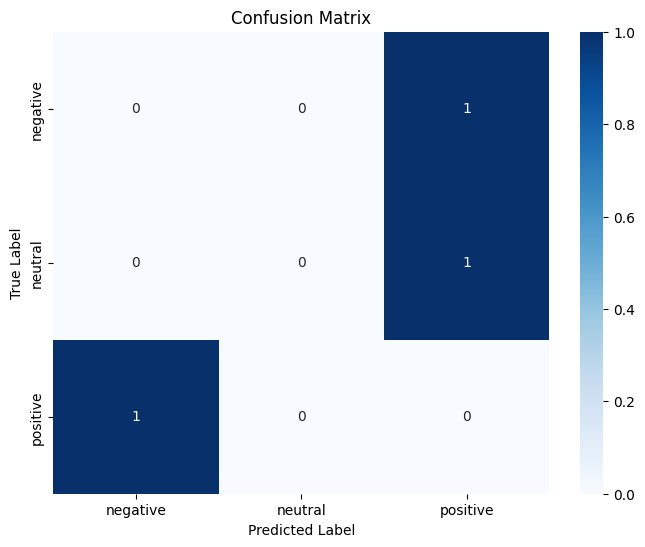

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get unique class labels from y_test and y_pred (to handle cases where a class might be missing in y_pred)
labels = sorted(list(set(y_test).union(set(y_pred))))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()